In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter

# Morse potential

For the Morse potential defined on $[-L/2,L/2]$ we have that $$W(r) = D_{e}(e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)})$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) =  D_e \int^{L/2}_{-L/2} (e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)})\cos{(2\pi zr/L)}dr . $$

In [3]:
from scipy.special import jv
from scipy.integrate import quad

# to do
L  = 10.
De = 1.0
re = 0.0
a  = 2.0

#@numba.jit(nopython=True)
def integrand_MORSE(r,z):
    #integrate numerically
    des = De*(np.exp(-2*a*(np.abs(r)-re))-2*np.exp(-a*(np.abs(r)-re)))*np.cos(z*r)
    return des 


def W_hat_MORSE(k):
    #integrate numerically
    W_hat_k = quad(integrand_MORSE,-L/2,L/2,args = (k,))
    return W_hat_k[0]


def matrix_MORSE(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_MORSE(k)/L
    return A_k

In [4]:
# For a number of temperatures and friction values, obtain largest eigenvalues.
def function_params(β,γ):

    k_max = 30  # number of wavenumbers to test.
    
    approximation_dimension = 30  # number of matrix rows to consider.
    maximum = np.max(np.real(np.linalg.eigvals(matrix_MORSE(0.,β,γ,L,approximation_dimension))))
    
    # find maximum eigenvalue for all wavenumbers
    for k in range(k_max - 1):
        #change to maximum real part
        partial_max = np.max(np.real(np.linalg.eigvals(matrix_MORSE(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
        #print(partial_max,maximum)
        if partial_max > maximum:
            maximum = partial_max
        partial_max = np.max(np.real(np.linalg.eigvals(matrix_MORSE(-2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
        #print(partial_max,maximum)
        if partial_max > maximum:
            maximum = partial_max
    spectral_radius = maximum
    
    return spectral_radius
    
def function():
    
    N_β = 1    # Number of temperature points.
    N_γ = 300      # Number of friction points.
    β_list = np.array([25])
    γ_list = np.linspace(0.01,3.0,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    
    spectral_radius = np.zeros((N_β,N_γ))  # store largest real part of eigenvalues here.
    
    # for all beta and gamma...
    for i in range(len(β_list)):
        print("beta: ", i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = function_params(β,γ)
            spectral_radius[i,j] = maximum
    
    return β_list,γ_list,spectral_radius



In [5]:
# For all temperatures and frictions, obtain largest eigenvalues.
β_list,γ_list,spectral_radius = function()

beta:  0


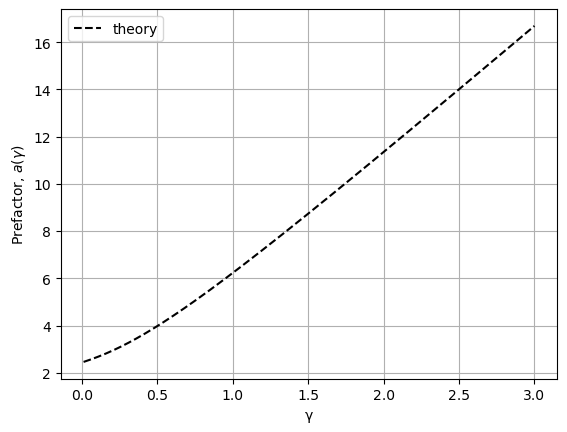

In [6]:
# plot the eigenvalue against beta
#arr = np.loadtxt('a_fit.csv', delimiter=",")
plt.plot(γ_list,1/(2*spectral_radius[0,:]),'--k',label='theory')
plt.grid()
plt.legend()
#plt.xscale('log')
#plt.yscale('log')
#plt.title('γ='+str(γ_list[gamma_idx]))
plt.xlabel('γ')
plt.ylabel('Prefactor, $a(γ)$')
plt.show()

In [20]:
np.savetxt("Morse_theory.csv", 1/(2*spectral_radius), delimiter=",")
np.savetxt("x_theory.csv", γ_list, delimiter=",")